# Exploratory Data Analysis Starter

## Import packages

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Shows plots in jupyter notebook
%matplotlib inline

# Set plot style
sns.set(color_codes=True)

---

## Loading data with Pandas

We need to load `client_data.csv` and `price_data.csv` into individual dataframes so that we can work with them in Python. For this notebook and all further notebooks, it will be assumed that the CSV files will the placed in the same file location as the notebook. If they are not, please adjust the directory within the `read_csv` method accordingly.

In [2]:
client_df = pd.read_csv('./client_data.csv')
price_df = pd.read_csv('./price_data.csv')

You can view the first 3 rows of a dataframe using the `head` method. Similarly, if you wanted to see the last 3, you can use `tail(3)`

In [3]:
client_df.head(3)

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,has_gas,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,origin_up,pow_max,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,t,0.0,25.44,25.44,2,678.99,3,lxidpiddsbxsbosboudacockeimpuepw,43.648,1
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,f,0.0,16.38,16.38,1,18.89,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.800,0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,f,0.0,28.60,28.60,1,6.60,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.856,0


In [4]:
price_df.head(3)

,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,038af19179925da21a25619c5a24b745,2015-01-01,0.151367,0.0,0.0,44.266931,0.0,0.0
1,038af19179925da21a25619c5a24b745,2015-02-01,0.151367,0.0,0.0,44.266931,0.0,0.0
2,038af19179925da21a25619c5a24b745,2015-03-01,0.151367,0.0,0.0,44.266931,0.0,0.0


---

## Descriptive statistics of data

### Data types

It is useful to first understand the data that you're dealing with along with the data types of each column. The data types may dictate how you transform and engineer features.

To get an overview of the data types within a data frame, use the `info()` method.

In [5]:
client_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        14606 non-null  object 
 1   channel_sales             14606 non-null  object 
 2   cons_12m                  14606 non-null  int64  
 3   cons_gas_12m              14606 non-null  int64  
 4   cons_last_month           14606 non-null  int64  
 5   date_activ                14606 non-null  object 
 6   date_end                  14606 non-null  object 
 7   date_modif_prod           14606 non-null  object 
 8   date_renewal              14606 non-null  object 
 9   forecast_cons_12m         14606 non-null  float64
 10  forecast_cons_year        14606 non-null  int64  
 11  forecast_discount_energy  14606 non-null  float64
 12  forecast_meter_rent_12m   14606 non-null  float64
 13  forecast_price_energy_p1  14606 non-null  float64
 14  foreca

In [6]:
price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193002 entries, 0 to 193001
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  193002 non-null  object 
 1   price_date          193002 non-null  object 
 2   price_off_peak_var  193002 non-null  float64
 3   price_peak_var      193002 non-null  float64
 4   price_mid_peak_var  193002 non-null  float64
 5   price_off_peak_fix  193002 non-null  float64
 6   price_peak_fix      193002 non-null  float64
 7   price_mid_peak_fix  193002 non-null  float64
dtypes: float64(6), object(2)
memory usage: 11.8+ MB


### Statistics

Now let's look at some statistics about the datasets. We can do this by using the `describe()` method.

In [7]:
client_df.describe()

,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_p1,forecast_price_energy_p2,forecast_price_pow_p1,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,pow_max,churn
count,1.460600e+04,1.460600e+04,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000
mean,1.592203e+05,2.809238e+04,16090.269752,1868.614880,1399.762906,0.966726,63.086871,0.137283,0.050491,43.130056,152.786896,24.565121,24.562517,1.292346,189.264522,4.997809,18.135136,0.097152
std,5.734653e+05,1.629731e+05,64364.196422,2387.571531,3247.786255,5.108289,66.165783,0.024623,0.049037,4.485988,341.369366,20.231172,20.230280,0.709774,311.798130,1.611749,13.534743,0.296175
min,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,3.300000,0.000000
25%,5.674750e+03,0.000000e+00,0.000000,494.995000,0.000000,0.000000,16.180000,0.116340,0.000000,40.606701,0.000000,14.280000,14.280000,1.000000,50.712500,4.000000,12.500000,0.000000
50%,1.411550e+04,0.000000e+00,792.500000,1112.875000,314.000000,0.000000,18.795000,0.143166,0.084138,44.311378,37.395000,21.640000,21.640000,1.000000,112.530000,5.000000,13.856000,0.000000
75%,4.076375e+04,0.000000e+00,3383.000000,2401.790000,1745.750000,0.000000,131.030000,0.146348,0.098837,44.311378,193.980000,29.880000,29.880000,1.000000,243.097500,6.000000,19.172500,0.000000
max,6.207104e+06,4.154590e+06,771203.000000,82902.830000,175375.000000,30.000000,599.310000,0.273963,0.195975,59.266378,15042.790000,374.640000,374.640000,32.000000,24570.650000,13.000000,320.000000,1.000000


In [8]:
price_df.describe()

,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
count,193002.000000,193002.000000,193002.000000,193002.000000,193002.000000,193002.000000
mean,0.141027,0.054630,0.030496,43.334477,10.622875,6.409984
std,0.025032,0.049924,0.036298,5.410297,12.841895,7.773592
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.125976,0.000000,0.000000,40.728885,0.000000,0.000000
50%,0.146033,0.085483,0.000000,44.266930,0.000000,0.000000
75%,0.151635,0.101673,0.072558,44.444710,24.339581,16.226389
max,0.280700,0.229788,0.114102,59.444710,36.490692,17.458221


---

## Data visualization

If you're working in Python, two of the most popular packages for visualization are `matplotlib` and `seaborn`. We highly recommend you use these, or at least be familiar with them because they are ubiquitous!

Below are some functions that you can use to get started with visualizations. 

In [9]:
def plot_stacked_bars(dataframe, title_, size_=(18, 10), rot_=0, legend_="upper right"):
    """
    Plot stacked bars with annotations
    """
    ax = dataframe.plot(
        kind="bar",
        stacked=True,
        figsize=size_,
        rot=rot_,
        title=title_
    )

    # Annotate bars
    annotate_stacked_bars(ax, textsize=14)
    # Rename legend
    plt.legend(["Retention", "Churn"], loc=legend_)
    # Labels
    plt.ylabel("Company base (%)")
    plt.show()

def annotate_stacked_bars(ax, pad=0.99, colour="white", textsize=13):
    """
    Add value annotations to the bars
    """

    # Iterate over the plotted rectanges/bars
    for p in ax.patches:
        
        # Calculate annotation
        value = str(round(p.get_height(),1))
        # If value is 0 do not annotate
        if value == '0.0':
            continue
        ax.annotate(
            value,
            ((p.get_x()+ p.get_width()/2)*pad-0.05, (p.get_y()+p.get_height()/2)*pad),
            color=colour,
            size=textsize
        )

def plot_distribution(dataframe, column, ax, bins_=50):
    """
    Plot variable distirbution in a stacked histogram of churned or retained company
    """
    # Create a temporal dataframe with the data to be plot
    temp = pd.DataFrame({"Retention": dataframe[dataframe["churn"]==0][column],
    "Churn":dataframe[dataframe["churn"]==1][column]})
    # Plot the histogram
    temp[["Retention","Churn"]].plot(kind='hist', bins=bins_, ax=ax, stacked=True)
    # X-axis label
    ax.set_xlabel(column)
    # Change the x-axis to plain style
    ax.ticklabel_format(style='plain', axis='x')

Thhe first function `plot_stacked_bars` is used to plot a stacked bar chart. An example of how you could use this is shown below:

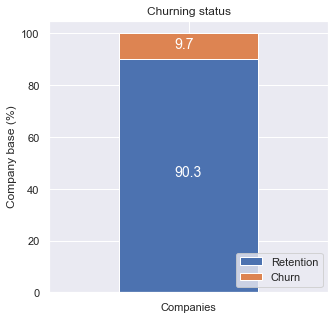

In [10]:
churn = client_df[['id', 'churn']]
churn.columns = ['Companies', 'churn']
churn_total = churn.groupby(churn['churn']).count()
churn_percentage = churn_total / churn_total.sum() * 100
plot_stacked_bars(churn_percentage.transpose(), "Churning status", (5, 5), legend_="lower right")

The second function `annotate_bars` is used by the first function, but the third function `plot_distribution` helps you to plot the distribution of a numeric column. An example of how it can be used is given below:

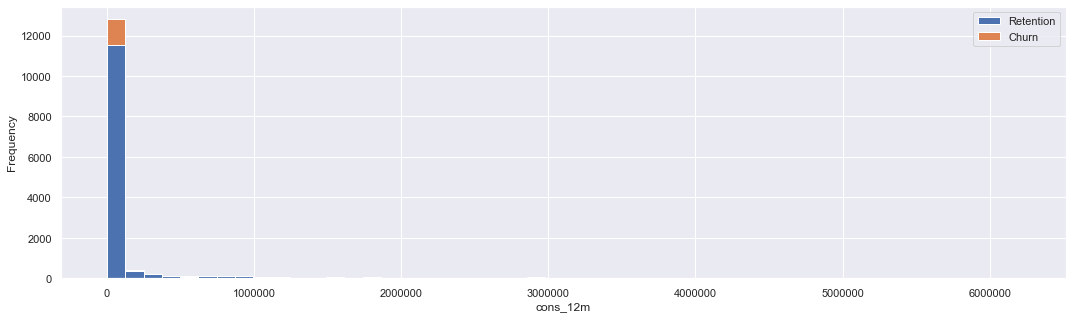

In [11]:
consumption = client_df[['id', 'cons_12m', 'cons_gas_12m', 'cons_last_month', 'imp_cons', 'has_gas', 'churn']]

fig, axs = plt.subplots(nrows=1, figsize=(18, 5))

plot_distribution(consumption, 'cons_12m', axs)

Task 1: Baseline Churn Analysis
# Objective: Understand the overall churn rate of PowerCo's customers

Status: Loading client data...
Status: Data loaded successfully!
Status: Calculating churn baseline...

--- Baseline Churn Summary ---
Retained Customers (0): 13187 (90.28%)
Churned Customers (1): 1419 (9.72%)
------------------------------
Status: Generating visualization...


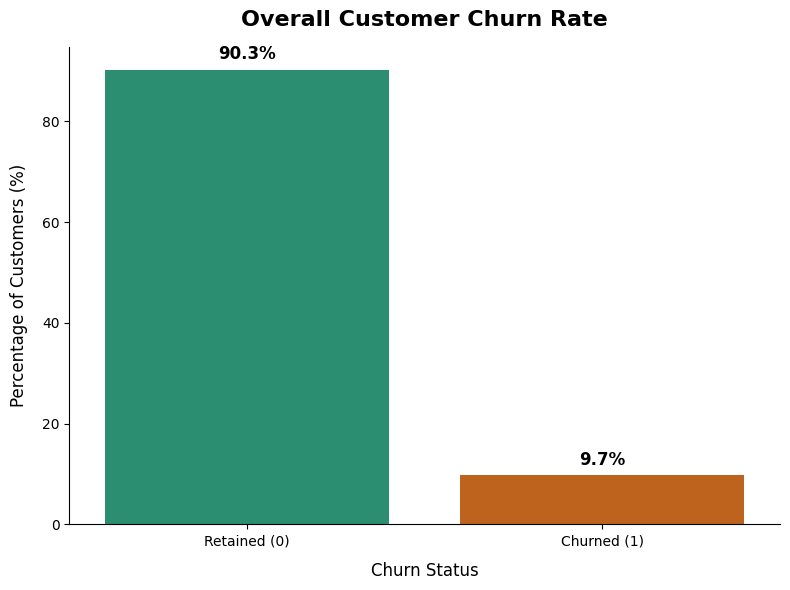

Status: Process completed!


In [5]:
# =========================================================
# Task 1: Baseline Churn Analysis
# Objective: Understand the overall churn rate of PowerCo's customers
# =========================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress unnecessary warnings
warnings.filterwarnings("ignore")

# 1. LOAD DATA
# Make sure 'client_data (1).csv' is in the exact same folder as this notebook
print("Status: Loading client data...")
try:
    client_df = pd.read_csv('client_data (1).csv')
    print("Status: Data loaded successfully!")
except FileNotFoundError:
    print("ERROR: File 'client_data (1).csv' not found. Please check the file name and path.")

# 2. CALCULATE CHURN
print("Status: Calculating churn baseline...")
churn_counts = client_df['churn'].value_counts()
churn_percentages = client_df['churn'].value_counts(normalize=True) * 100

print("\n--- Baseline Churn Summary ---")
print(f"Retained Customers (0): {churn_counts[0]} ({churn_percentages[0]:.2f}%)")
print(f"Churned Customers (1): {churn_counts[1]} ({churn_percentages[1]:.2f}%)")
print("-" * 30)

# 3. CREATE VISUALIZATION
print("Status: Generating visualization...")
plt.figure(figsize=(8, 6))

# Using a clean corporate color palette
ax = sns.barplot(x=churn_percentages.index, y=churn_percentages.values, palette=['#1b9e77', '#d95f02'])

# Add professional titles and labels
plt.title('Overall Customer Churn Rate', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Churn Status', fontsize=12, labelpad=10)
plt.ylabel('Percentage of Customers (%)', fontsize=12, labelpad=10)
plt.xticks(ticks=[0, 1], labels=['Retained (0)', 'Churned (1)'])

# Add data labels (annotations) on top of the bars
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', 
                xytext=(0, 5), 
                textcoords='offset points',
                fontsize=12, fontweight='bold')

# Clean up the borders (remove top and right spines for a cleaner look)
sns.despine()
plt.tight_layout()
plt.show()

print("Status: Process completed!")

Status: Generating consumption distribution plots...


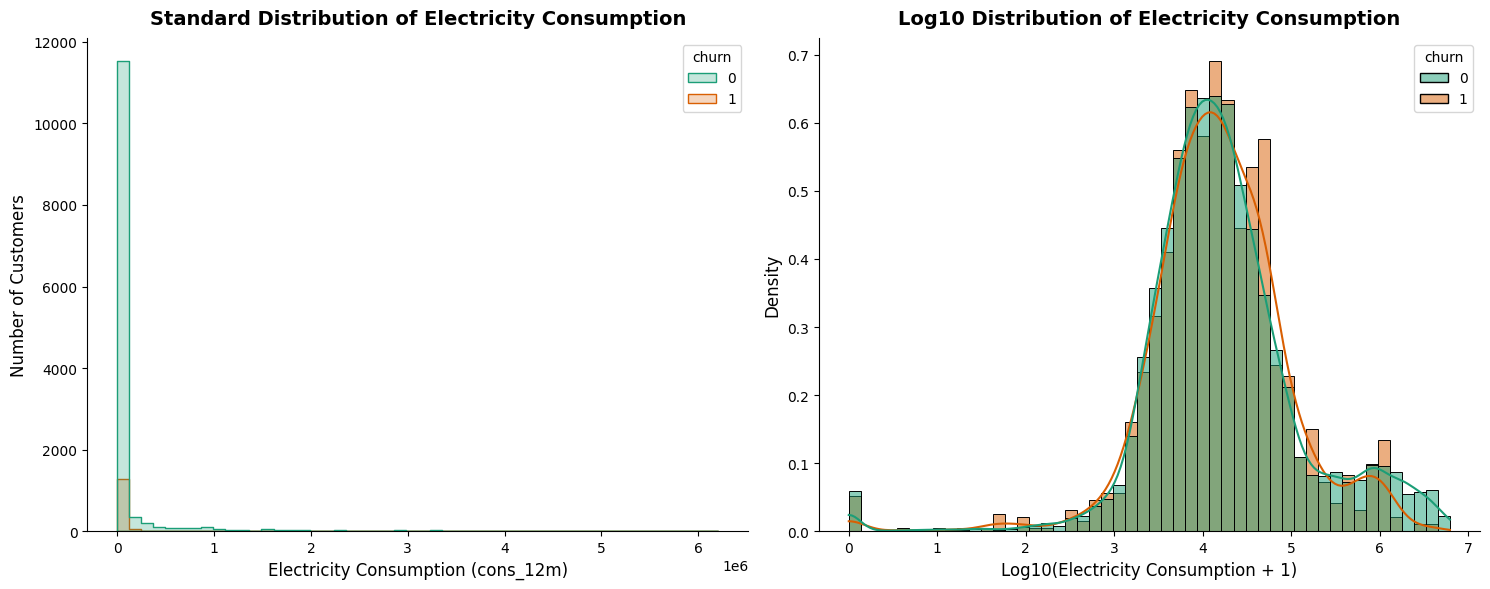

Status: Plots generated successfully!


In [6]:
# =========================================================
# Task 2: Energy Consumption Distribution Analysis
# Objective: Analyze if electricity consumption impacts churn
# =========================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Status: Generating consumption distribution plots...")

# Set up the matplotlib figure with two subplots side-by-side
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))

# --- PLOT 1: Standard Histogram ---
# Using step element for cleaner overlapping histograms
sns.histplot(data=client_df, x='cons_12m', hue='churn', bins=50, 
             palette=['#1b9e77', '#d95f02'], element='step', 
             common_norm=False, ax=axes[0])

axes[0].set_title('Standard Distribution of Electricity Consumption', fontsize=14, fontweight='bold', pad=10)
axes[0].set_xlabel('Electricity Consumption (cons_12m)', fontsize=12)
axes[0].set_ylabel('Number of Customers', fontsize=12)

# --- PLOT 2: Log-Scaled Histogram ---
# We use log10(x + 1) to handle the extreme outliers and avoid log(0) errors
client_df['cons_12m_log'] = np.log10(client_df['cons_12m'] + 1)

sns.histplot(data=client_df, x='cons_12m_log', hue='churn', bins=50, kde=True,
             palette=['#1b9e77', '#d95f02'], stat='density', 
             common_norm=False, ax=axes[1])

axes[1].set_title('Log10 Distribution of Electricity Consumption', fontsize=14, fontweight='bold', pad=10)
axes[1].set_xlabel('Log10(Electricity Consumption + 1)', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)

# Clean up layout
sns.despine()
plt.tight_layout()
plt.show()

print("Status: Plots generated successfully!")

Status: Loading price data...
Status: Price data loaded successfully!
Status: Calculating price changes between Jan and Dec...
Status: Generating price sensitivity visualization...


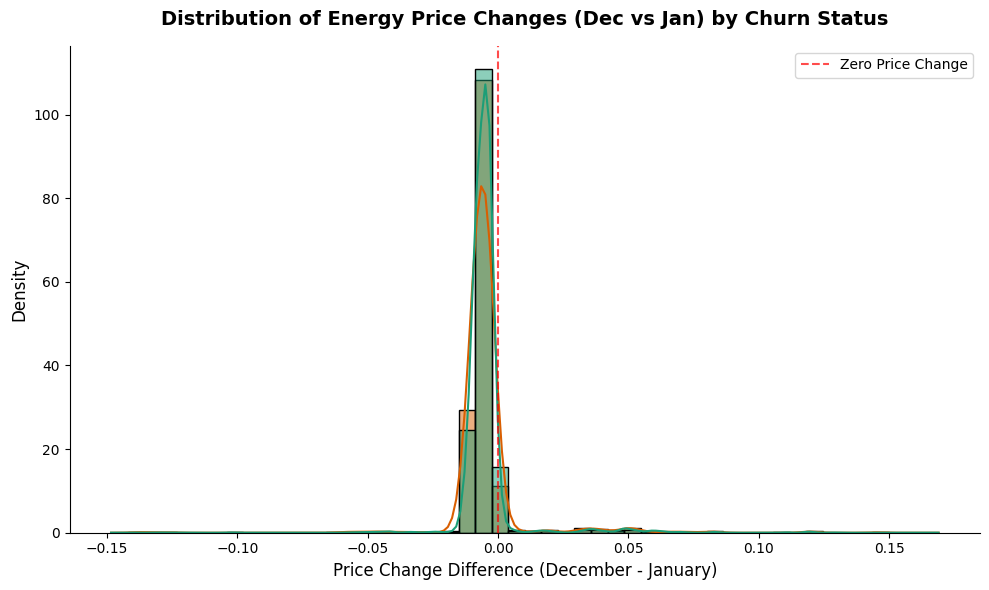

Status: Process completed!


In [7]:
# =========================================================
# Task 3: Price Sensitivity Analysis (Hypothesis Testing)
# Objective: Check if price increases drive customer churn
# =========================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Status: Loading price data...")
try:
    price_df = pd.read_csv('price_data (1).csv')
    print("Status: Price data loaded successfully!")
except FileNotFoundError:
    print("ERROR: File 'price_data (1).csv' not found. Check your file name.")

# 1. PREPARE THE DATA: Convert date column to datetime object
price_df['price_date'] = pd.to_datetime(price_df['price_date'])

# 2. EXTRACT PRICES: Get prices for January (Start) and December (End)
# We will focus on 'price_off_peak_var' (variable price for off-peak energy) as the primary indicator
print("Status: Calculating price changes between Jan and Dec...")
jan_prices = price_df[price_df['price_date'].dt.month == 1][['id', 'price_off_peak_var']]
dec_prices = price_df[price_df['price_date'].dt.month == 12][['id', 'price_off_peak_var']]

# Rename columns to distinguish them before merging
jan_prices = jan_prices.rename(columns={'price_off_peak_var': 'price_jan'})
dec_prices = dec_prices.rename(columns={'price_off_peak_var': 'price_dec'})

# Merge Jan and Dec prices per customer
price_diff = pd.merge(jan_prices, dec_prices, on='id')

# 3. CALCULATE PRICE INCREASE: End of year price minus beginning of year price
price_diff['price_increase'] = price_diff['price_dec'] - price_diff['price_jan']

# 4. MERGE WITH CHURN DATA (Assuming client_df is still in memory from Task 1 & 2)
churn_data = client_df[['id', 'churn']]
merged_data = pd.merge(price_diff, churn_data, on='id')

# 5. VISUALIZATION
print("Status: Generating price sensitivity visualization...")
plt.figure(figsize=(10, 6))

# Plot the distribution of price changes
sns.histplot(data=merged_data, x='price_increase', hue='churn', bins=50, kde=True,
             palette=['#1b9e77', '#d95f02'], stat='density', common_norm=False)

plt.title('Distribution of Energy Price Changes (Dec vs Jan) by Churn Status', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Price Change Difference (December - January)', fontsize=12)
plt.ylabel('Density', fontsize=12)

# Add a vertical line at 0 (No price change)
plt.axvline(x=0, color='red', linestyle='--', alpha=0.7, label='Zero Price Change')
plt.legend()

sns.despine()
plt.tight_layout()
plt.show()

print("Status: Process completed!")

## Executive Summary: Exploratory Data Analysis (EDA)

Based on the preliminary data analysis of PowerCo's customer and pricing datasets, we can draw the following conclusions:

1. **Class Imbalance:** The overall churn rate is approximately **9.72%**. The vast majority of customers (90.28%) remain retained.
2. **Consumption Distribution:** Electricity consumption volume does not have a distinct impact on churn probability. The distribution of energy usage is virtually identical between retained and churned customers.
3. **Hypothesis Rejected (Price Sensitivity):** The hypothesis that price sensitivity is the primary driver of customer churn is **unsupported by the data**. When plotting the difference in variable off-peak prices between December and January, the distribution of price changes is identical for both churned and retained customers. 

**Next Steps:** Since price changes do not strongly correlate with churn, we must conduct further feature engineering to uncover other potential drivers (e.g., tenure length, margin profitability, or contract renewals) before building our predictive model.